In [1]:
import os
if "KERAS_BACKEND" not in os.environ:                # ensure the backend is set
    os.environ["KERAS_BACKEND"] = "torch"

import math
import numpy as np  
import numba as nb
import seaborn as sns
import pandas as pd
import keras
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import truncnorm

import bayesflow as bf
import tensorflow as tf

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
I0000 00:00:1777840694.133492   51114 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def ddmc_prior(): 
    # as in amortized_dmc.pdf, Updated $sd_r$ fixed, rounded values
    lower = 0
    upper = np.inf

    means = np.array([360, 35, 60, 0.6, 20, 20, 120, 120])
    sds = np.array([25, 8, 13, 0.15, 8, 8, 40, 40])

    a = (lower - means) / sds
    b = (upper - means) / sds

    priors = truncnorm.rvs(a, b, loc=means, scale=sds)

    return dict(mu_r=priors[0], sd_r=priors[1], b=priors[2], muc=priors[3], 
                A1=priors[4], A2=priors[5], tau1=priors[6], tau2=priors[7])


def ddmc_trial(muc, A1, A2, tau1, tau2, b, ndts, noise, t, sigma = 4.0, dt = 1): 
    # Simulate multiple DDMC trials in parallel

    # Prepare output
    num_trials, _ = noise.shape
    rts = np.full(num_trials, -1.0)
    resps = np.full(num_trials, -1)

    X0 = np.random.beta(3, 3, size=num_trials) * (2 * b) - b    # initial pos

    # with a1 = a2 = 2
    mu_a1 = A1 / tau1 * np.exp(1 - t / tau1) * (1 - t / tau1)
    mu_a2 = A2 / tau2 * np.exp(1 - t / tau2) * (1 - t / tau2)
    mu_t = mu_a1 + mu_a2 + muc

    dX = mu_t[None, :] * dt + sigma * np.sqrt(dt) * noise

    X = np.cumsum(dX, axis=1) + X0[:, None]

    crossed_upper = X >= b
    crossed_lower = X <= -b
    crossed_any = crossed_upper | crossed_lower

    # First crossing index for each trial
    first_crossing = np.argmax(crossed_any, axis=1)
    has_crossed = np.any(crossed_any, axis=1)

    # Fill only for trials that crossed
    idx = np.where(has_crossed)[0]
    crossing_times = t[first_crossing[idx]]


    ndts_crossed = ndts[idx]    # nondecision times only for trials that crossed
    rts[idx] = (crossing_times + ndts_crossed) / 1000  # convert to seconds

    # get response type
    resp_hit = X[idx, first_crossing[idx]]
    resps[idx] = (resp_hit >= b).astype(int)

    return np.c_[rts, resps]


def ddmc_experiment(num_obs, muc, A1, A2, tau1, tau2, b, mu_r, sd_r): 
    max_time = 1500#5000
    dt = 1

    # precompute time vector and noise
    t = np.linspace(start=dt, stop=max_time, num=int(max_time/dt))
    noise = np.random.normal(size = (num_obs, len(t)))
    ndts = np.random.normal(size = num_obs, loc=mu_r, scale=sd_r)

    out = np.zeros((num_obs, 2))        # to store rt and resp

    # congruency conditions (equal split)
    quarter = int(np.ceil(num_obs / 4))
    conditions = np.repeat(np.arange(4), quarter)[:num_obs]

    # simulate CONG-CONG trials (A1, A2)
    out[:quarter] = ddmc_trial(
        muc=muc, A1=A1, A2=A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[:quarter], noise=noise[:quarter]
    )
    # simulate CONG-INCONG trials (A1, -A2)
    out[quarter:quarter*2] = ddmc_trial(
        muc=muc, A1=A1, A2=-A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter:quarter*2], noise=noise[quarter:quarter*2]
    )
    # simulate INCONG-CONG trials (-A1, A2)
    out[quarter*2:quarter*3] = ddmc_trial(
        muc=muc, A1=-A1, A2=A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter*2:quarter*3], noise=noise[quarter*2:quarter*3]
    )
    # simulate INCONG-INCONG trials (-A1, -A2)
    out[quarter*3:] = ddmc_trial(
        muc=muc, A1=-A1, A2=-A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter*3:], noise=noise[quarter*3:]
    )
    

    return dict(rt = out[:, 0], resp = out[:, 1], conditions = conditions, 
    num_obs = num_obs)

# Number of observations (trials) in each batch randomly sampled
def meta(batch_size, num_obs = None): 
    if num_obs == None:
        num_obs = np.random.randint(50, 600)
    return dict(num_obs = num_obs)
    
ddmc_experiment(num_obs = 12, muc = 0.5, A1 = 60, A2 = 60, 
tau1 = 10, tau2 = 170, b = 50, mu_r = 300, sd_r = 0)

{'rt': array([0.311, 0.444, 0.304, 0.345, 0.303, 0.367, 0.308, 0.343, 0.337,
        0.411, 0.304, 0.302]),
 'resp': array([1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.]),
 'conditions': array([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3]),
 'num_obs': 12}

In [4]:
simulator = bf.simulators.make_simulator([ddmc_prior, ddmc_experiment], meta_fn = meta)

sim_data = simulator.sample(64)
print("Shape of rt:", sim_data["rt"].shape)
print("Shape of response:", sim_data["resp"].shape)
print("Shape of condition:", sim_data["conditions"].shape)

Shape of rt: (64, 500)
Shape of response: (64, 500)
Shape of condition: (64, 500)


### Prior samples

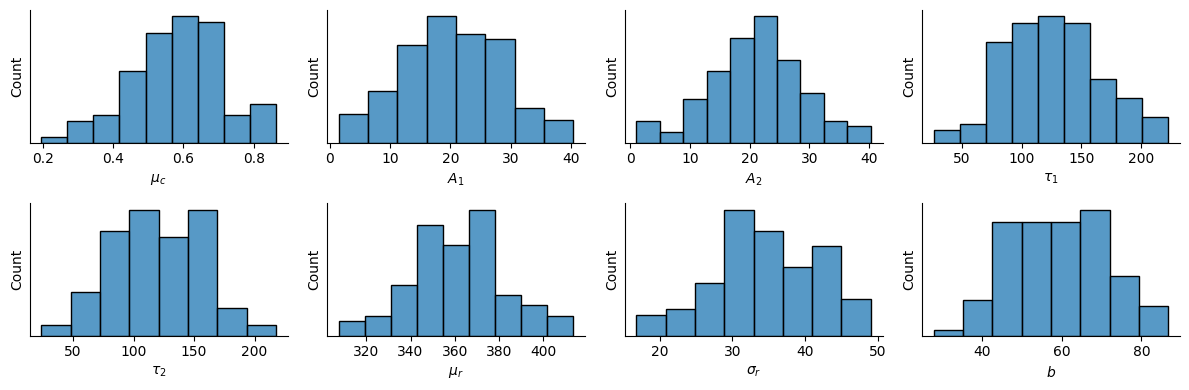

In [5]:
params = ["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"]
params_names = [
    r"$\mu_c$", r"$A_1$", r"$A_2$", r"$\tau_1$", r"$\tau_2$", r"$\mu_r$", 
    r"$\sigma_r$", r"$b$"
]
example_sim = simulator.sample(100)
f, axarr = plt.subplots(2, 4, figsize=(12, 4))
for i in range(len(params)): 
    ax = axarr.flat[i]
    sns.histplot(example_sim[params[i]].flatten(), alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_xlabel(params_names[i])
    ax.set_yticks([])
f.tight_layout()

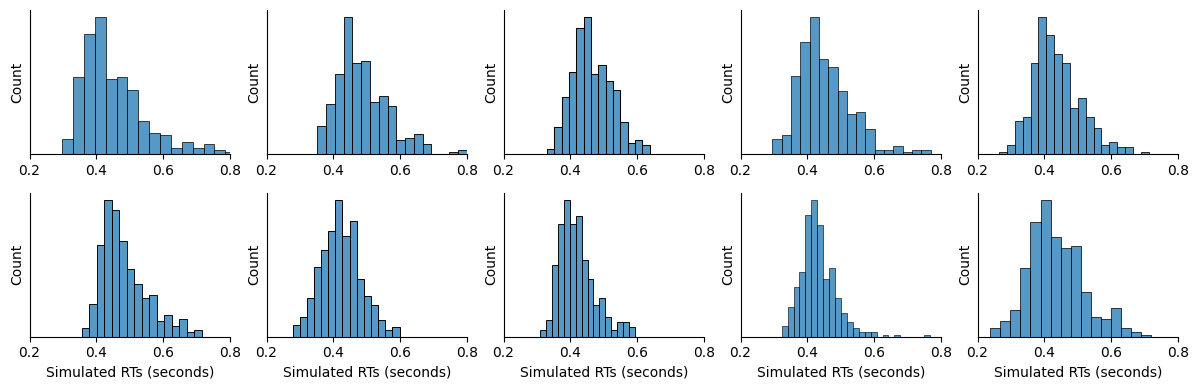

In [6]:
example_sim = simulator.sample(10)
f, axarr = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axarr.flat):
    sns.histplot(example_sim['rt'][i], alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_xlim(0.2, 0.8)
    ax.set_yticks([])
    if i > 4:
        ax.set_xlabel("Simulated RTs (seconds)")
f.tight_layout()

In [154]:
#prior_samples = simulator.sample(100)
#f = bf.diagnostics.plots.pairs_samples(
#    prior_samples, 
#    variable_keys=params, 
#    variable_names=params_names
#)
#
#f.fig.set_size_inches(7, 7)
# note: weird looking histograms also in SIR-example on https://github.com/bayesflow-org/bayesflow/blob/main/examples/SIR_Posterior_Estimation.ipynb

In [7]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .sqrt("num_obs")
    .as_set(["rt", "resp", "conditions"])
    .concatenate(
        ["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"], 
        into="inference_variables"
    )
    .concatenate(["rt", "resp", "conditions"], into="summary_variables")
    .standardize(
        include="inference_variables", 
        mean=[0.6, 20, 20, 120, 120, 360, 35, 60], 
        std=[0.15, 8, 8, 40, 40, 360, 35, 60]
    )
    .rename("num_obs", "inference_conditions")
)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    initial_learning_rate=5e-4,
    inference_network=bf.networks.FlowMatching(
        dropout=0.01070354852467715
    ),
    summary_network=bf.networks.SetTransformer(
        dropout=0.01070354852467715, 
        num_seeds=7, 
        summary_dim=24,             # 4 * dim of inference variables (4 * 1 * 8)
        embed_dims=(128, 128)
    ),
    inference_variables = ["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"],
    inference_conditions = ["num_obs"], 
    summary_variables = ["rt", "resp", "conditions"],
    checkpoint_filepath = Path(os.getcwd()).resolve(),  # save in cwd
    checkpoint_name = "DDMC_1500"                 # file name
)

In [9]:
processed_draws = adapter(sim_data)
print(processed_draws["summary_variables"].shape)
print(processed_draws["inference_conditions"].shape)
print(processed_draws["inference_variables"].shape)

(64, 500, 3)
(64, 1)
(64, 8)


In [ ]:
history = workflow.fit_online(
    epochs=3, 
    num_batches_per_epoch=25,
    batch_size=32
)

#history = workflow.fit_online(
#    epochs=200,
#    num_batches_per_epoch=250,
#    batch_size=64
#)

In [10]:
approximator = keras.saving.load_model("keras-objects/MDMC_1704.keras")

### Diagnostics

In [12]:
val_sims = simulator.sample(200)

In [ ]:
post_draws = approximator.sample(conditions=val_sims, num_samples=300)

In [237]:
#f = bf.diagnostics.plots.pairs_posterior(
#    estimates=post_draws, 
#    targets=val_sims,
#    variable_names = params_names,
#    dataset_id=0
#)

In [15]:
#f = bf.diagnostics.plots.recovery(
#    estimates = post_draws, 
#    targets = val_sims,
#    variable_names = params_names
#)

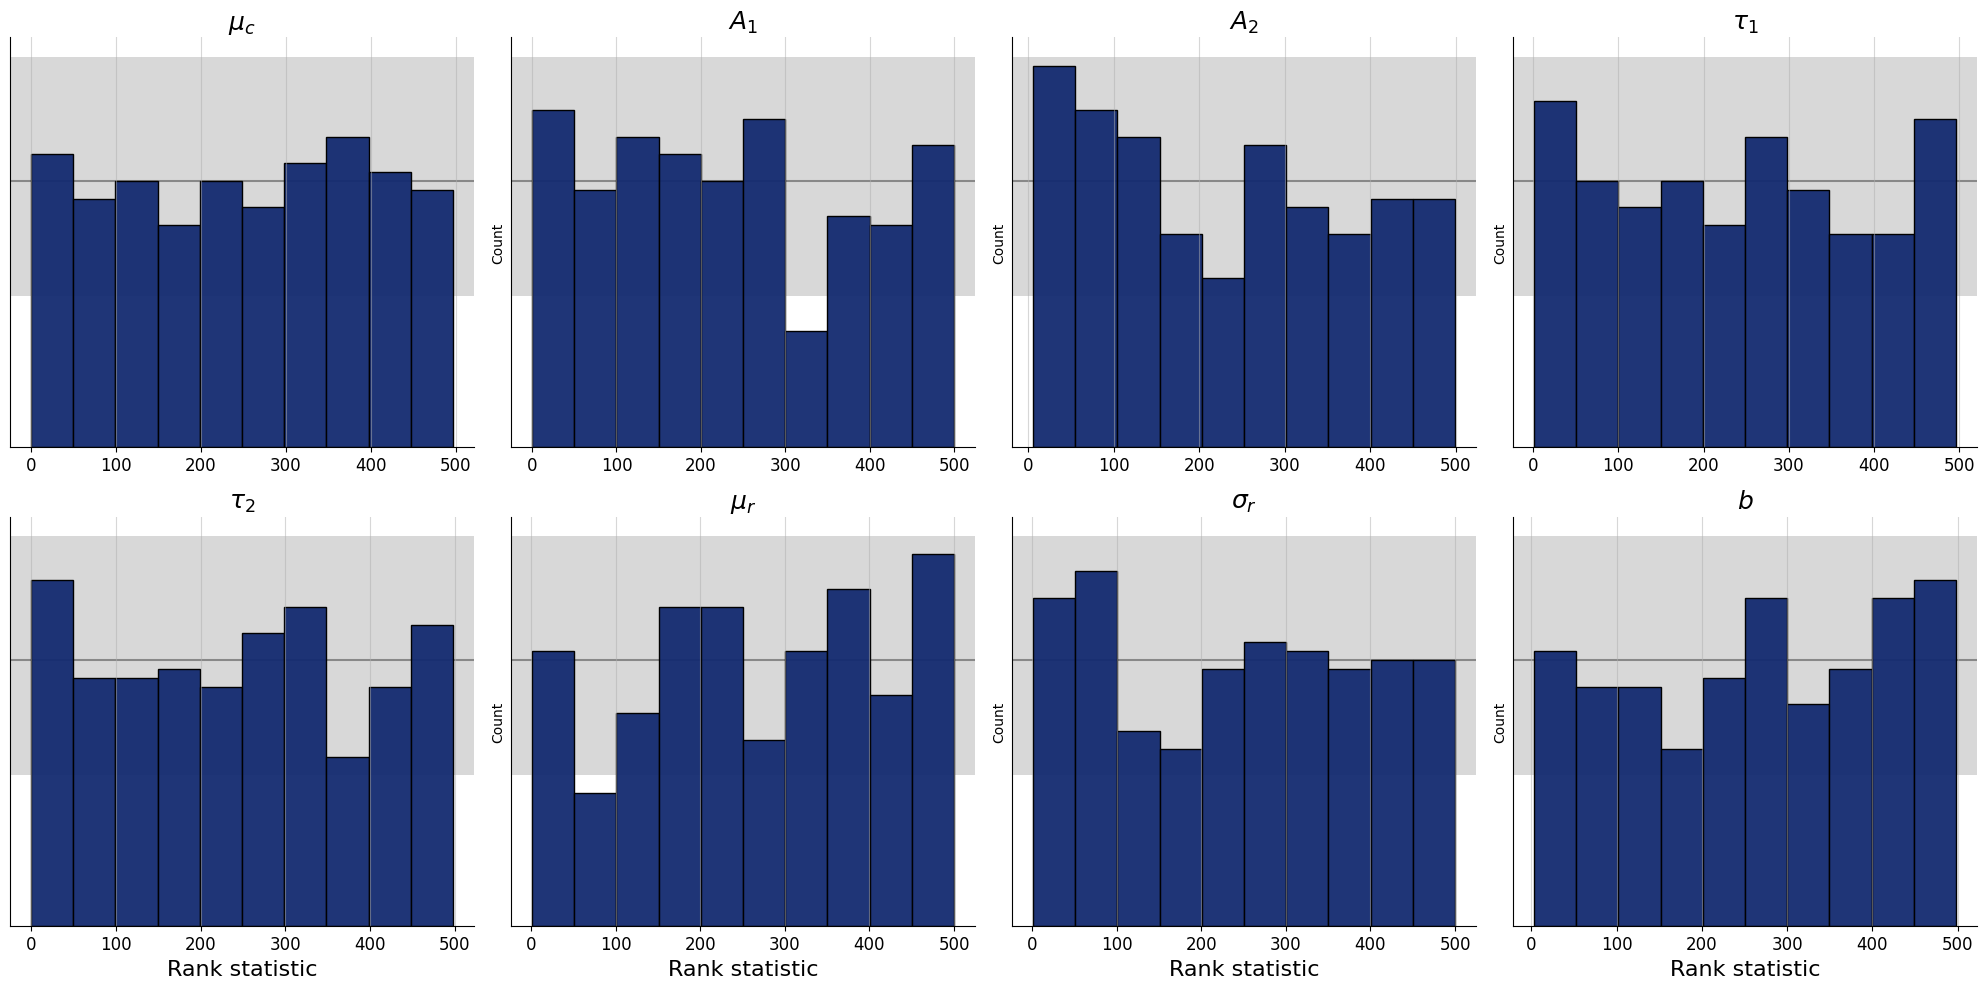

In [238]:
f = bf.diagnostics.plots.calibration_histogram(
    estimates = post_draws, 
    targets = val_sims,
    variable_names = params_names
)

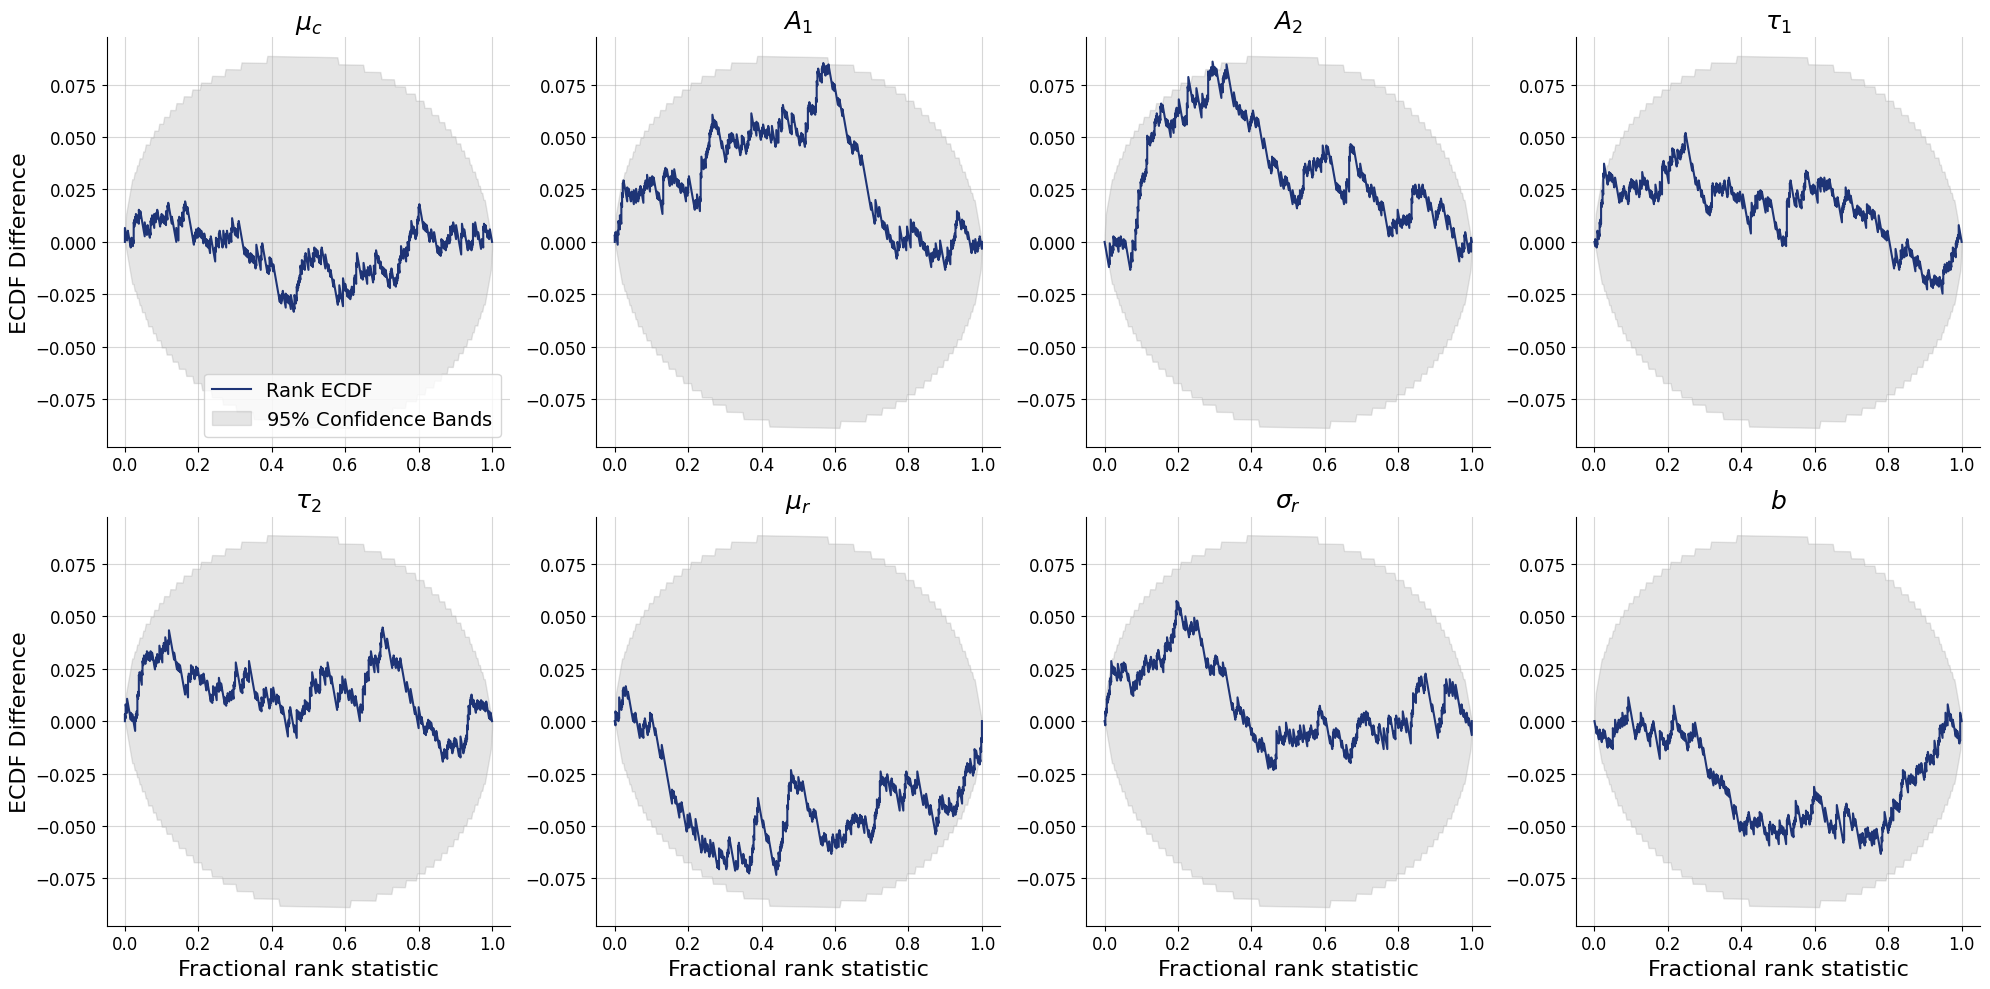

In [ ]:
f = bf.diagnostics.plots.calibration_ecdf(
    estimates = post_draws, 
    targets = val_sims,
    variable_names = params_names
)

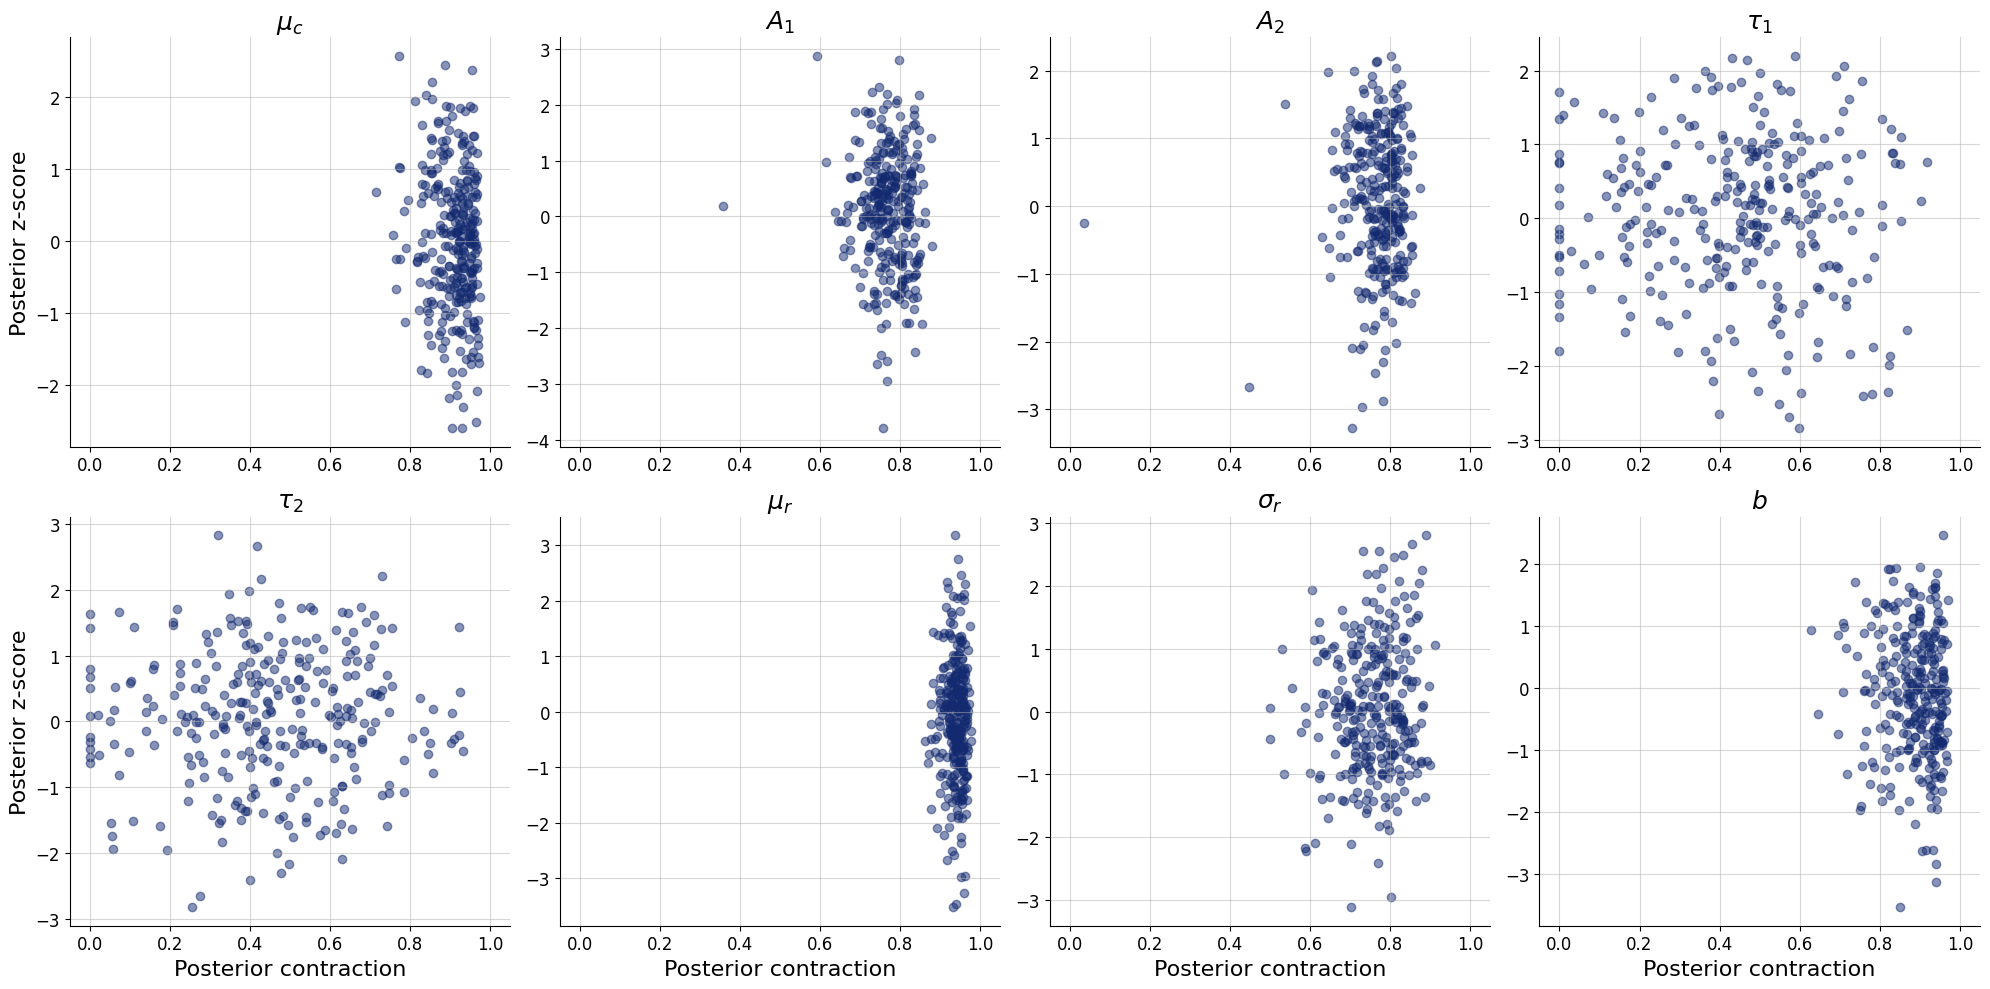

In [163]:
f = bf.diagnostics.plots.z_score_contraction(
    estimates = post_draws, 
    targets = val_sims, 
    variable_names = params_names
)

# Inference

In [ ]:
# load data
directory = "../data/raw/Exp1a_data/combi/"
filelist = os.listdir(directory)

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f), sep=r"\s+", header=None)
     for f in filelist],
    ignore_index=True
)

print(str(df))

# set colnames
# column names combi: “subj”, “block”, “catch”, “stimulus”, “stimuluscolor”, 
# “flankercolor”, “flanker”, “stroop”, “xr”, “r”, “corr”, “rt”, “re”
df.columns = ["subject", "block", "catch", "stimulus", 
"stimuluscolor", "flankercolor", "flanker", "stroop", "xr", "resp", "corr", "rt", 
"re"]
df.drop(['re', 'xr'], inplace=True, axis=1)

df = df.drop(df[df.catch == 1].index)           # remove catch trials

df["rt"] = df["rt"] / 1000.0      # convert to s

# separate condition columns for both processes
df["CI1"] = np.where(df["flanker"] == 0, "congruent", "incongruent") # Flanker
df["CI2"] = np.where(df["stroop"] == 0, "congruent", "incongruent")  # Stroop

# condition column both processes
df["CI"] = np.where(
    (df["CI1"] == "congruent") & (df["CI2"] == "congruent"), "CC",
    np.where(
        (df["CI1"] == "incongruent") & (df["CI2"] == "congruent"), "IC",
        np.where(
            (df["CI1"] == "congruent") & (df["CI2"] == "incongruent"), "CI", 
            "II"
        )
    )
)

df["conditions"] = df["CI"].astype("category").cat.codes

       0   1   2   3   4   5   6   7   8   9   10    11  12
0      11   1   0   0   1   1   1   0   2   2   1  2712   1
1      11   1   0   0   0   2   0   1   1   1   1  1083   1
2      11   1   0   3   3   3   1   1   4   4   1   695   1
3      11   1   0   3   0   1   0   0   1   1   1  1082   0
4      11   1   0   2   3   3   1   0   4   4   1  1270   1
...    ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   ...  ..
18427  13   4   1   3   3   2   0   1   4   4   1   701   1
18428  13   4   0   3   3   3   1   1   4   4   1   728   1
18429  13   4   0   0   3   3   0   0   4   1   0   666   1
18430  13   4   0   0   3   3   1   0   4   4   1   900   1
18431  13   4   0   1   1   0   0   1   2   2   1   775   1

[18432 rows x 13 columns]


In [ ]:
df_grouped = df.groupby(by="subject")

# min/max number of trials in any group
max_n = max(len(group) for _, group in df_grouped)
min_n = min(len(group) for _, group in df_grouped)
print(max_n, min_n)

data_inference_dict = {
    key: np.array([
        group[key].values[:min_n].reshape(min_n, 1)
        for _, group in df_grouped
    ])
    for key in ['rt', 'resp', 'conditions']
}

data_inference_dict["num_obs"] = np.sum(data_inference_dict["rt"], axis=1)

print({key: value.shape for key, value in data_inference_dict.items()}) # shapes

576 576
dict_keys([1, 2, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])
{'rt': (24, 576, 1), 'resp': (24, 576, 1), 'conditions': (24, 576, 1), 'num_obs': (24, 1)}


In [189]:
test_data = simulator.sample(500)

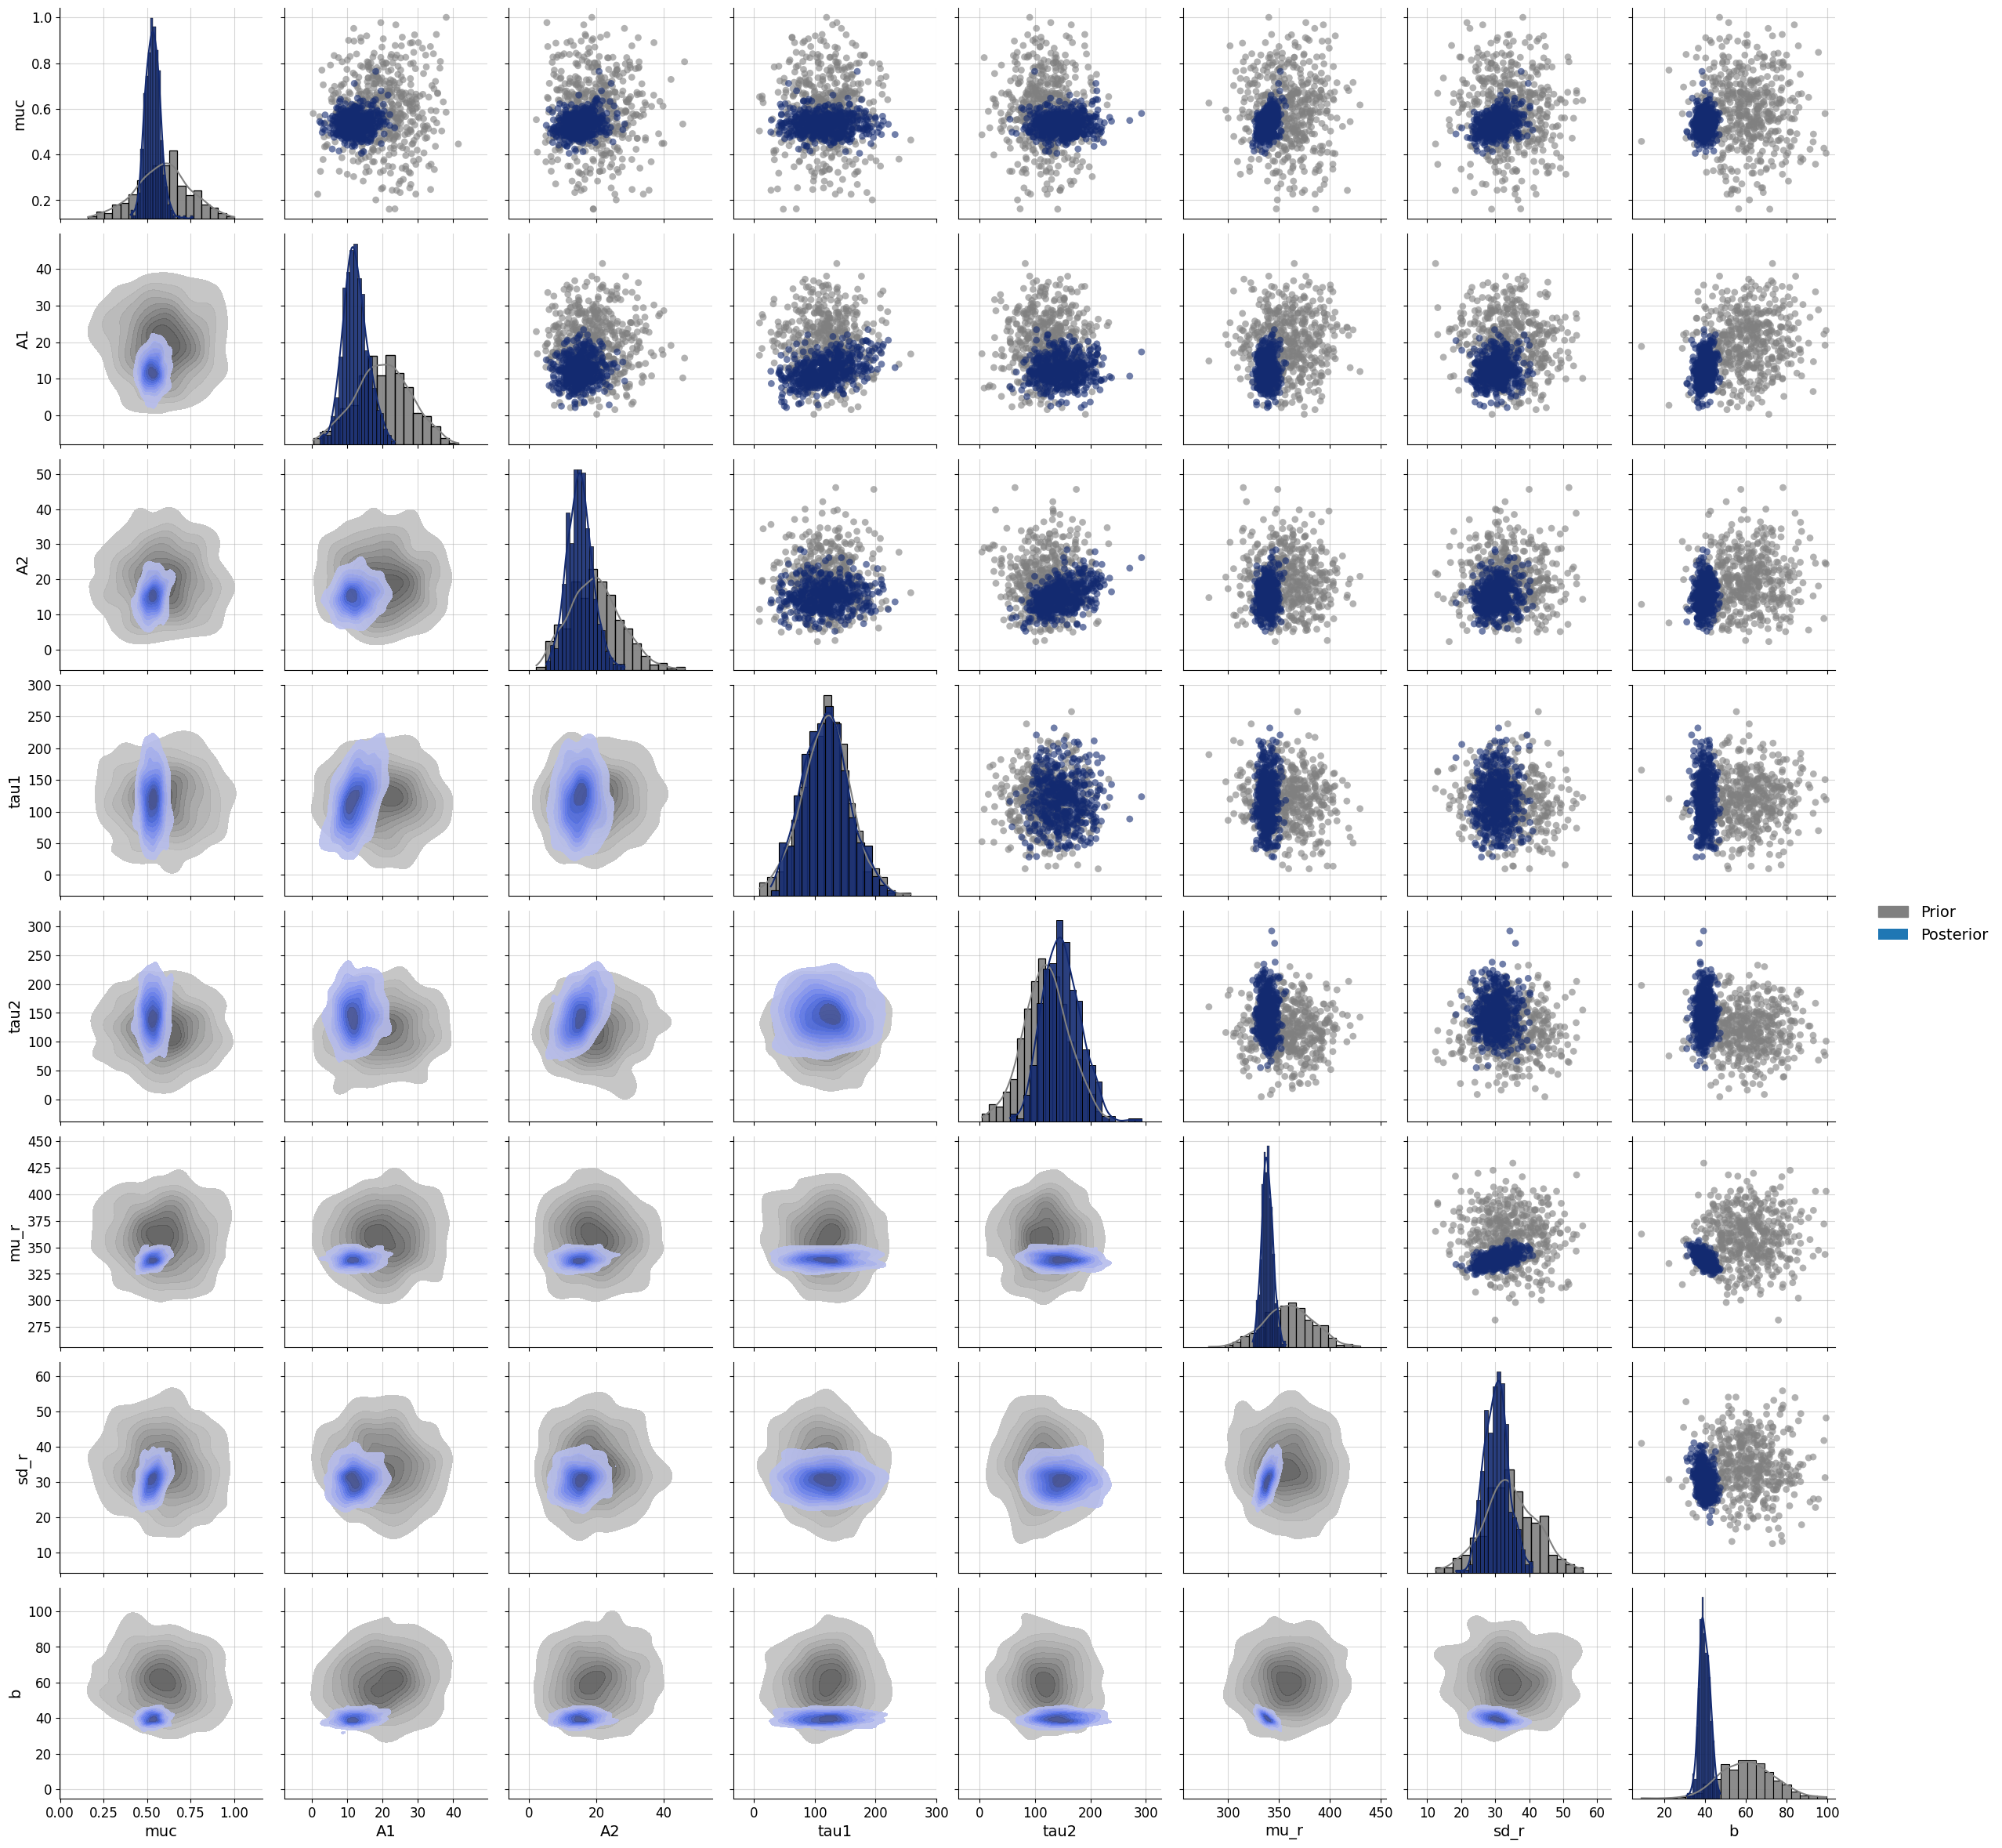

In [194]:
posterior = {key: value[0] for key, value in post_draws.items()}  # 1st participant
priors = dict(
    muc=test_data["muc"], A1=test_data["A1"], A2=test_data["A2"],
    tau1=test_data["tau1"], tau2=test_data["tau2"],
    mu_r=test_data["mu_r"], sd_r=test_data["sd_r"],
    b=test_data["b"]
)

f=bf.diagnostics.pairs_posterior(estimates=posterior, priors=priors)

In [214]:
# all Participants
#TODO look into hierarchical
participants = df["subject"].unique()
data = df

all_part_samples = []
for i, subj in enumerate(participants): 
    subj_data = data[data["subject"] == subj]
    
    subj_inference_dict = {
        key: np.array([subj_data[key].values.reshape(len(subj_data), 1)
    ])
    for key in ['rt', 'resp', 'conditions']
    }
    subj_inference_dict["num_obs"] = np.sum(subj_inference_dict["rt"], axis=1)

    samples = approximator.sample(conditions=subj_inference_dict, num_samples=200)

    # save samples
    samples_flat = {k: v.flatten() for k, v in samples.items()}
    subj_data_samples = pd.DataFrame(samples_flat)
    subj_data_samples["subject"] = subj

    all_part_samples.append(subj_data_samples)


#    print(subj, {key: value.shape for key, value in subj_inference_dict.items()}) # shapes

Sampling: 100%|██████████| 1/1 [00:09<00:00,  9.37s/batch]


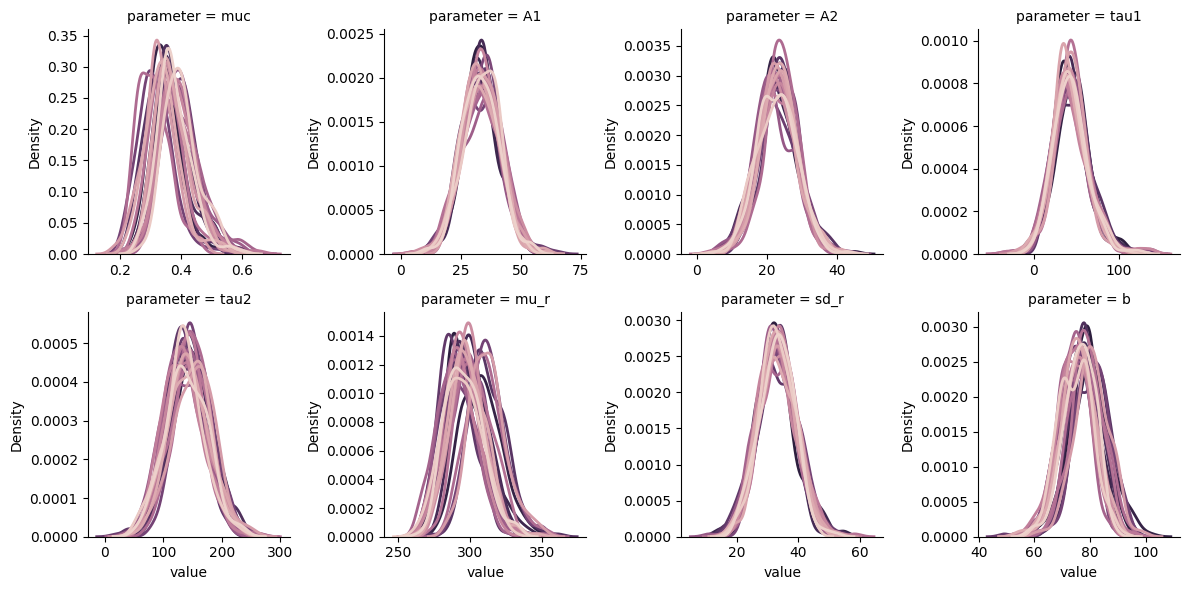

In [ ]:
df = pd.concat(all_part_samples, ignore_index=True)
df_long = df.melt(
    id_vars="subject",
    value_vars=["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"],
    var_name="parameter",
    value_name="value"
)

f = sns.FacetGrid(
    df_long, col="parameter",col_wrap=4, sharex=False, sharey=False
)
f.map_dataframe(sns.kdeplot, x="value", hue="subject", linewidth=2)

plt.show()